# 实验四：生成模型（VAE、GAN 与 Diffusion）

**课程**：深度学习导论  
**类型**：PyTorch 完整应用（VAE/GAN 训练 + Diffusion 前向可视化与预训练推理脚手架，不训练扩散模型）。  
**输出**：公式推导填空、核心函数补全、可视化结果、锚定问题作答、思考与附加题作答。

---

**AI使用说明**：本实验允许并鼓励负责任地使用 AI 辅助理解、查文档、调试、润色表达。不设抽查答辩、不禁止长段 AI 生成。


## 1. 环境与依赖

- 需 `torch`、`torchvision`、`matplotlib`、`numpy`；GPU 可加速训练与推理。
- 数据：MNIST，记作 $\mathbf{X}\in\mathbb{R}^{B\times1\times28\times28}$。
- VAE：编码器输出 $(\mu, \log\sigma^2)$，通过重参数化得到潜变量 $z$。
- GAN：生成器 $G$ 与判别器 $D$ 对抗训练，观察模式崩溃现象。
- Diffusion：仅实现前向加噪 $q(x_t|x_0)$ 与预训练 pipeline 推理脚手架（不训练扩散模型）。

---

**Markdown 公式语法参考**

本 Notebook 的 Markdown 支持 LaTeX 数学公式：行内公式用 `$...$`，独立行公式用 `$$...$$`。  
常用：`\frac{}`、`\partial`、`\sum`、`\mathbf{X}`、`\mathcal{L}`。


## 2. 生成模型核心数学推导 (Mathematical Foundations)

本节目标是为后续 VAE 和 Diffusion 模型的纯代码实现建立严谨的数学映射。

**记号约定**：标量小写 $a$；向量粗体小写 $\mathbf{x}$；张量粗体大写 $\mathbf{X}$；常数矩阵标识为 $\mathbf{I}$；逐元素相乘用 $\odot$ 表示。

---

### 2.1 变分推断的重参数化 (Reparameterization Trick)

在 VAE 中，为了使随机采样过程对网络参数连续可导，我们将从分布 $\mathcal{N}(\mu, \sigma^2)$ 中的直接采样，转化为从标准正态分布 $\mathcal{N}(0, \mathbf{I})$ 中采样的白噪声 $\epsilon$ 的仿射变换。代码中为了数值稳定性，通常网络直接输出对数方差 $\log \sigma^2$。

$$
\begin{aligned}
z &= \mu + \sigma \odot \epsilon, \\
\sigma &= \exp\left(\frac{1}{2}\log \sigma^2\right),\quad \epsilon\sim\mathcal{N}(0,\mathbf{I})
\end{aligned}
$$

### 2.2 VAE 损失与 KL 散度闭式解 (Closed-Form KL)

VAE 的优化目标是最大化证据下界 (ELBO)，等价于最小化总损失 $\mathcal{L}_{\mathrm{VAE}}$。其中 $\mathcal{L}_{\mathrm{rec}}$ 为重构惩罚（通常用二元交叉熵 BCE 或 MSE），$\mathcal{L}_{\mathrm{KL}}$ 为强制隐变量后验分布逼近先验 $\mathcal{N}(0, \mathbf{I})$ 的散度惩罚。

$$
\mathcal{L}_{\mathrm{VAE}}=\mathcal{L}_{\mathrm{rec}}+\mathcal{L}_{\mathrm{KL}}
$$

当两个分布均为高斯分布时，多维独立隐空间的 KL 散度具有如下闭式解析解（此公式将直接对应代码中张量的算术运算）：

$$
\mathcal{L}_{\mathrm{KL}}=-\frac{1}{2}\sum_j\left(1+\log\sigma_j^2-\mu_j^2-\sigma_j^2\right)
$$

### 2.3 扩散模型前向加噪 (Diffusion Forward Process)

标准扩散模型 (DDPM) 通过马尔可夫链向数据 $x_0$ 逐步注入高斯噪声。利用重参数化技巧，任意时间步 $t$ 的状态 $x_t$ 可以直接由原始干净数据 $x_0$ 闭式表达，其中 $\bar{\alpha}_t$ 为累乘的噪声控制参数。

$$
q(x_t|x_0)=\mathcal{N}(x_t;\sqrt{\bar{\alpha}_t}x_0,(1-\bar{\alpha}_t)\mathbf{I})
$$

即采样公式可写作：
$$
\begin{aligned}
x_t &= \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\,\epsilon,\quad \epsilon\sim\mathcal{N}(0,\mathbf{I})
\end{aligned}
$$


**【请填写】** 在下方补全核心公式推导：


$$
\begin{aligned}
\frac{\partial z}{\partial \mu} &= \mathbf{I}, \\
\frac{\partial z}{\partial \log\sigma^2} &= \frac{1}{2}\exp\left(\frac{1}{2}\log\sigma^2\right)\odot\epsilon
\end{aligned}
$$



$$
\begin{aligned}
\mathbb{E}[x_t|x_0] &= \sqrt{\bar{\alpha}_t}x_0\\
\mathrm{Var}(x_t|x_0) &= (1-\bar{\alpha}_t)\mathbf{I}
\end{aligned}
$$


In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from matplotlib import gridspec

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


### 数据加载（MNIST）

**输入**：MNIST 图像（`1×28×28`）与标签。  
**输出**：`train_loader`（供 VAE、GAN 与 Diffusion 前向可视化复用）。


In [2]:
batch_size = 128
train_transform = transforms.ToTensor()
train_set = datasets.MNIST(root="./data", train=True, download=True, transform=train_transform)

# 为保证本地/CPU 调试能在几分钟内完成，截取 10000 张图像的子集
subset_size = 10000
perm = torch.randperm(len(train_set), generator=torch.Generator().manual_seed(42))[:subset_size]
train_set = torch.utils.data.Subset(train_set, perm.tolist())

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)

x_demo, y_demo = next(iter(train_loader))
print("train size:", len(train_set), "| batch shape:", x_demo.shape, "| label shape:", y_demo.shape)


train size: 10000 | batch shape: torch.Size([128, 1, 28, 28]) | label shape: torch.Size([128])


## 3. 变分自编码器 (VAE) 与流形可视化


In [3]:
latent_dim_vae = 2

class VAE(nn.Module):
    def __init__(self, latent_dim: int = 2):
        super().__init__()
        # ================================
        # Encoder: 使用步长为 2 的卷积进行空间降采样
        # ================================
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 14x14 -> 7x7
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

        # ================================
        # Decoder: 使用转置卷积恢复空间分辨率
        # ================================
        self.decoder_fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # 7x7 -> 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # 14x14 -> 28x28
            nn.Sigmoid()
        )

    def encode(self, x: torch.Tensor):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def decode(self, z: torch.Tensor):
        h = self.decoder_fc(z)
        h = h.view(-1, 64, 7, 7) # 重塑回空间特征图
        return self.decoder_conv(h)

    @staticmethod
    def reparameterize(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        global_fn = globals().get("reparameterize")
        if callable(global_fn):
            return global_fn(mu, logvar)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

### 3.1 重参数化技巧（Reparameterization Trick）

本小节数学公式已统一收敛到第 2 节。请直接依据第 2 节推导完成下方实现。


**【请填写】**：根据上文推导，在下方围栏内实现 `reparameterize` 函数。


In [4]:
def reparameterize(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    """重参数化：z = mu + std * eps"""
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)

    # ==========================
    # 【请填写】实现重参数化
    # ==========================
    z = mu + std * eps
    # ==========================

    return z


### 3.2 VAE 损失（重构项 + KL 项）

本小节数学公式已统一收敛到第 2 节。请直接依据第 2 节推导完成下方实现。


**【请填写】**：根据上文推导，在下方围栏内实现 `vae_loss_fn` 函数。


In [5]:
def vae_loss_fn(recon_x: torch.Tensor, x: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor):
    """返回 total_loss, bce_loss, kl_loss"""

    # ==========================
    # 【请填写】实现 BCE + KL 损失
    # 提示：
    # 1. 展平 recon_x 和 x (或者不展平直接算)，计算全局 BCE sum: F.binary_cross_entropy(..., reduction='sum')
    # 2. 计算全局 KL sum: -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    # 3. total_loss = (BCE + KL) / x.size(0)
    # ==========================
    bce_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = (bce_loss + kl_loss) / x.size(0)
    # ==========================

    return total_loss, bce_loss, kl_loss


In [6]:
# 【维度自检】确保 VAE 前向与 Loss 逻辑能正常跑通单步
if "vae" not in globals():
    vae = VAE(latent_dim=latent_dim_vae).to(device)
_x = torch.rand(2, 1, 28, 28).to(device)
_recon, _mu, _logvar = vae(_x)
_loss, _bce, _kl = vae_loss_fn(_recon, _x, _mu, _logvar)
print(f"=> VAE 维度自检通过！(Total Loss: {_loss.item():.4f})")


=> VAE 维度自检通过！(Total Loss: 572.5568)


### 3.3 VAE 训练说明

- 先完成上方两个函数填空，再运行本单元。
- 默认训练约 50 个 epoch，用于后续二维潜空间网格可视化。
- 若本地算力受限，可先将 `epochs_vae` 临时改小做流程验证。


In [7]:
epochs_vae = 50
vae = VAE(latent_dim=latent_dim_vae).to(device)
opt_vae = torch.optim.Adam(vae.parameters(), lr=1e-3)

vae_loss_curve = []
for epoch in range(1, epochs_vae + 1):
    vae.train()
    running_loss = 0.0
    for x, _ in train_loader:
        x = x.to(device)
        recon_x, mu, logvar = vae(x)
        total_loss, bce_loss, kl_loss = vae_loss_fn(recon_x, x, mu, logvar)

        opt_vae.zero_grad()
        total_loss.backward()
        opt_vae.step()

        running_loss += total_loss.item() * x.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    vae_loss_curve.append(epoch_loss)
    print(f"[VAE] Epoch {epoch}/{epochs_vae} | loss={epoch_loss:.4f}")


[VAE] Epoch 1/50 | loss=294.9232
[VAE] Epoch 2/50 | loss=205.2052
[VAE] Epoch 3/50 | loss=192.7597
[VAE] Epoch 4/50 | loss=186.1724
[VAE] Epoch 5/50 | loss=182.1474
[VAE] Epoch 6/50 | loss=179.7139
[VAE] Epoch 7/50 | loss=178.0382
[VAE] Epoch 8/50 | loss=176.7380
[VAE] Epoch 9/50 | loss=175.5227
[VAE] Epoch 10/50 | loss=174.5060
[VAE] Epoch 11/50 | loss=173.5588
[VAE] Epoch 12/50 | loss=172.7206
[VAE] Epoch 13/50 | loss=172.0620
[VAE] Epoch 14/50 | loss=171.2425
[VAE] Epoch 15/50 | loss=170.5499
[VAE] Epoch 16/50 | loss=169.9073
[VAE] Epoch 17/50 | loss=169.2911
[VAE] Epoch 18/50 | loss=168.4931
[VAE] Epoch 19/50 | loss=167.8499
[VAE] Epoch 20/50 | loss=167.3994
[VAE] Epoch 21/50 | loss=166.7727
[VAE] Epoch 22/50 | loss=166.1765
[VAE] Epoch 23/50 | loss=165.7508
[VAE] Epoch 24/50 | loss=165.2860
[VAE] Epoch 25/50 | loss=164.8843
[VAE] Epoch 26/50 | loss=164.4279
[VAE] Epoch 27/50 | loss=164.0410
[VAE] Epoch 28/50 | loss=163.7076
[VAE] Epoch 29/50 | loss=163.3482
[VAE] Epoch 30/50 | los

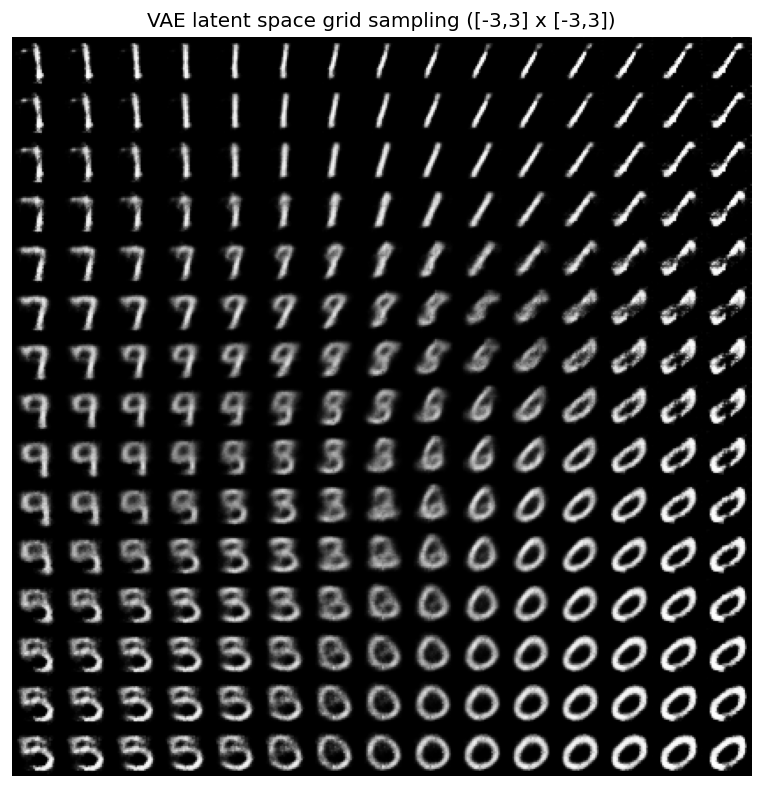

In [8]:
def plot_vae_latent_grid(model: VAE, grid_size: int = 20, bound: float = 3.0):
    model.eval()
    xs = np.linspace(-bound, bound, grid_size)
    ys = np.linspace(-bound, bound, grid_size)
    canvas = np.zeros((28 * grid_size, 28 * grid_size), dtype=np.float32)

    with torch.no_grad():
        for i, y in enumerate(ys):
            for j, x in enumerate(xs):
                z = torch.tensor([[x, y]], dtype=torch.float32, device=device)
                recon = model.decode(z).squeeze(0).squeeze(0).cpu().numpy()
                r0, r1 = i * 28, (i + 1) * 28
                c0, c1 = j * 28, (j + 1) * 28
                canvas[r0:r1, c0:c1] = recon

    plt.figure(figsize=(8, 8))
    plt.imshow(canvas, cmap="gray")
    plt.title("VAE latent space grid sampling ([-3,3] x [-3,3])")
    plt.axis("off")
    plt.show()

plot_vae_latent_grid(vae, grid_size=15, bound=3.0)


**【现象拓展】**
观察上图的生成网格，你可能会发现：中心与左下角区域的数字（如 1、0）边缘清晰，而右上角边缘区域（坐标接近 [3,3]）生成的图像呈现明显的噪点或“马赛克”感；此外，不同数字的交界处出现了重影。
请结合 VAE 的 KL 散度目标以及均方/交叉熵重构误差的特性，尝试解释这两个现象。

**【请填写】** 在下方 Markdown cell 中作答。

中心区域生成的数字更清晰，是因为 KL 散度把近似后验约束到接近标准正态分布，训练过程中潜变量样本主要集中在原点附近的高概率区域；这些区域被解码器充分见过，因此解码更稳定。右上角等远离中心的边缘位置属于低概率区域，训练支持较少，解码器更多是在外推，所以容易出现噪点、块状纹理或边缘破碎。数字交界处的重影来自连续潜空间和像素级 BCE/MSE 式重构目标：当同一潜变量位置对应多种可能数字时，解码器倾向输出条件平均形态，于是会混合不同类别的笔画。

**【理论锚定】** 为什么必须使用重参数化技巧，而不能直接从 $\mathcal{N}(\mu,\sigma^2)$ 中“黑箱采样”后直接反向传播？请聚焦“计算图连续可导路径”和“梯度是否会与编码器参数解耦”作答（2-4 句）。

**【请填写】** 在下方 Markdown cell 中作答。


不能直接黑箱采样，是因为从 $\mathcal{N}(\mu,\sigma^2)$ 采样这一随机操作本身不提供关于编码器输出 $\mu$、$\log\sigma^2$ 的连续可导路径，反向传播时梯度会与编码器参数解耦。重参数化把随机性拆成与参数无关的 $\epsilon\sim\mathcal{N}(0,\mathbf{I})$，再令 $z=\mu+\sigma\odot\epsilon$，这样 $z$ 就成为 $\mu$ 和 $\log\sigma^2$ 的显式可导函数，重构损失与 KL 项的梯度都能回传到编码器。


## 4. 生成对抗网络 (GAN) 与模式崩溃


In [9]:
latent_dim_gan = 32

class Generator(nn.Module):
    def __init__(self, latent_dim: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),
        )

    def forward(self, z: torch.Tensor):
        out = self.net(z)
        return out.view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # 注意：由于使用了 BCEWithLogitsLoss，判别器 D 的最后一层不要加 Sigmoid，直接输出 raw logits 以保证数值稳定性。
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
        )

    def forward(self, x: torch.Tensor):
        x_flat = x.view(x.size(0), -1)
        return self.net(x_flat)


### 4.1 对抗目标与数值稳定性

判别器与生成器的目标可写为：

$$
\max_D\; \mathbb{E}_{x\sim p_{\text{data}}}[\log D(x)] + \mathbb{E}_{z\sim p(z)}[\log(1-D(G(z)))]
$$

$$
\min_G\; \mathbb{E}_{z\sim p(z)}[\log(1-D(G(z)))]
\quad\text{或}\quad
\max_G\; \mathbb{E}_{z\sim p(z)}[\log D(G(z))]
$$

本实验使用 `nn.BCEWithLogitsLoss()`，因此判别器输出应为 logits（raw logits，不加 Sigmoid）。


**【请填写】**：根据上文推导，在下方围栏内实现 `gan_train_step` 函数。


In [10]:
criterion = nn.BCEWithLogitsLoss()

def gan_train_step(real, G, D, opt_g, opt_d, criterion, latent_dim, device):
    batch_size = real.size(0)
    real = real.to(device)
    real_label = torch.ones(batch_size, 1, device=device)
    fake_label = torch.zeros(batch_size, 1, device=device)

    # 注意：由于使用了 BCEWithLogitsLoss，判别器 D 的最后一层不要加 Sigmoid，直接输出 raw logits 以保证数值稳定性。
    z = torch.randn(batch_size, latent_dim, device=device)
    fake = G(z)
    d_real = D(real)
    d_fake = D(fake.detach())

    # ==========================
    # 【请填写】判别器损失
    # ==========================
    loss_d_real = criterion(d_real, real_label)
    loss_d_fake = criterion(d_fake, fake_label)
    loss_d = loss_d_real + loss_d_fake
    # ==========================

    opt_d.zero_grad()
    loss_d.backward()
    opt_d.step()

    z2 = torch.randn(batch_size, latent_dim, device=device)
    fake2 = G(z2)
    g_fake = D(fake2)

    # ==========================
    # 【请填写】生成器损失（希望 D(fake) -> 1）
    # ==========================
    loss_g = criterion(g_fake, real_label)
    # ==========================

    opt_g.zero_grad()
    loss_g.backward()
    opt_g.step()

    return loss_d.item(), loss_g.item()


In [11]:
# 【维度自检】确保 GAN 博弈更新步骤无 NaN 且维度匹配
if "G" not in globals():
    G = Generator(latent_dim=latent_dim_gan).to(device)
if "D" not in globals():
    D = Discriminator().to(device)
if "opt_d" not in globals():
    opt_d = torch.optim.Adam(D.parameters(), lr=5e-3, betas=(0.5, 0.999))
if "opt_g" not in globals():
    opt_g = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.5, 0.999))
_real = torch.randn(4, 1, 28, 28).to(device)
_ld, _lg = gan_train_step(_real, G, D, opt_g, opt_d, criterion, latent_dim_gan, device)
print(f"=> GAN 单步博弈自检通过！(Loss D: {_ld:.4f}, Loss G: {_lg:.4f})")


=> GAN 单步博弈自检通过！(Loss D: 1.4783, Loss G: 1.7444)


### 4.2 模式崩溃设置

为更容易观察模式崩溃，设置不平衡超参数：`lr_d >> lr_g`，并使用较小潜变量维度与纯 ReLU 生成器骨干。


In [12]:
# ==========================================
# 【探索】顺序运行三种超参数组合，见证不同的训练灾难
# ==========================================
gan_modes = {
    'd_overpower': (5e-3, 1e-4),       # 判别器碾压：D 学习率是 G 的 50 倍
    'g_overpower': (2e-4, 2e-3),       # 生成器暴走：G 学习率是 D 的 10 倍
    'fragile_balance': (2e-4, 2e-4),   # 勉强平衡：相对保守但仍不稳定
}

epochs_gan = 10
snapshot_epochs = {1, 3, 5, 7, 10}
gan_results = {}

for gan_mode, (lr_d, lr_g) in gan_modes.items():
    print(f"=== 正在运行 GAN 模式: {gan_mode} (lr_d={lr_d}, lr_g={lr_g}) ===")

    G = Generator(latent_dim=latent_dim_gan).to(device)
    D = Discriminator().to(device)

    opt_d = torch.optim.Adam(D.parameters(), lr=lr_d, betas=(0.5, 0.999))
    opt_g = torch.optim.Adam(G.parameters(), lr=lr_g, betas=(0.5, 0.999))

    gan_d_losses, gan_g_losses = [], []
    gan_snapshots = {}

    for epoch in range(1, epochs_gan + 1):
        d_sum, g_sum, n_steps = 0.0, 0.0, 0
        for real, _ in train_loader:
            loss_d, loss_g = gan_train_step(real, G, D, opt_g, opt_d, criterion, latent_dim_gan, device)
            d_sum += loss_d
            g_sum += loss_g
            n_steps += 1

        d_epoch = d_sum / max(n_steps, 1)
        g_epoch = g_sum / max(n_steps, 1)
        gan_d_losses.append(d_epoch)
        gan_g_losses.append(g_epoch)

        if epoch in snapshot_epochs:
            G.eval()
            with torch.no_grad():
                z_vis = torch.randn(16, latent_dim_gan, device=device)
                gan_snapshots[epoch] = G(z_vis).detach().cpu()
            G.train()

        print(f"[GAN:{gan_mode}] Epoch {epoch}/{epochs_gan} | D={d_epoch:.4f} | G={g_epoch:.4f}")

    gan_results[gan_mode] = {
        'd_losses': gan_d_losses,
        'g_losses': gan_g_losses,
        'snapshots': gan_snapshots,
    }


=== 正在运行 GAN 模式: d_overpower (lr_d=0.005, lr_g=0.0001) ===
[GAN:d_overpower] Epoch 1/10 | D=0.5176 | G=18.5231
[GAN:d_overpower] Epoch 2/10 | D=0.1513 | G=7.9565
[GAN:d_overpower] Epoch 3/10 | D=0.4446 | G=4.1184
[GAN:d_overpower] Epoch 4/10 | D=0.0262 | G=5.3300
[GAN:d_overpower] Epoch 5/10 | D=0.0580 | G=5.1231
[GAN:d_overpower] Epoch 6/10 | D=0.3828 | G=2.9719
[GAN:d_overpower] Epoch 7/10 | D=0.1792 | G=3.1526
[GAN:d_overpower] Epoch 8/10 | D=0.0467 | G=5.2935
[GAN:d_overpower] Epoch 9/10 | D=0.3531 | G=5.1048
[GAN:d_overpower] Epoch 10/10 | D=0.0630 | G=5.2966
=== 正在运行 GAN 模式: g_overpower (lr_d=0.0002, lr_g=0.002) ===
[GAN:g_overpower] Epoch 1/10 | D=1.2659 | G=0.9942
[GAN:g_overpower] Epoch 2/10 | D=1.2349 | G=1.1522
[GAN:g_overpower] Epoch 3/10 | D=1.3083 | G=0.9153
[GAN:g_overpower] Epoch 4/10 | D=1.3187 | G=0.8398
[GAN:g_overpower] Epoch 5/10 | D=1.3103 | G=0.8557
[GAN:g_overpower] Epoch 6/10 | D=1.2582 | G=0.9235
[GAN:g_overpower] Epoch 7/10 | D=1.1896 | G=1.1829
[GAN:g_overpo

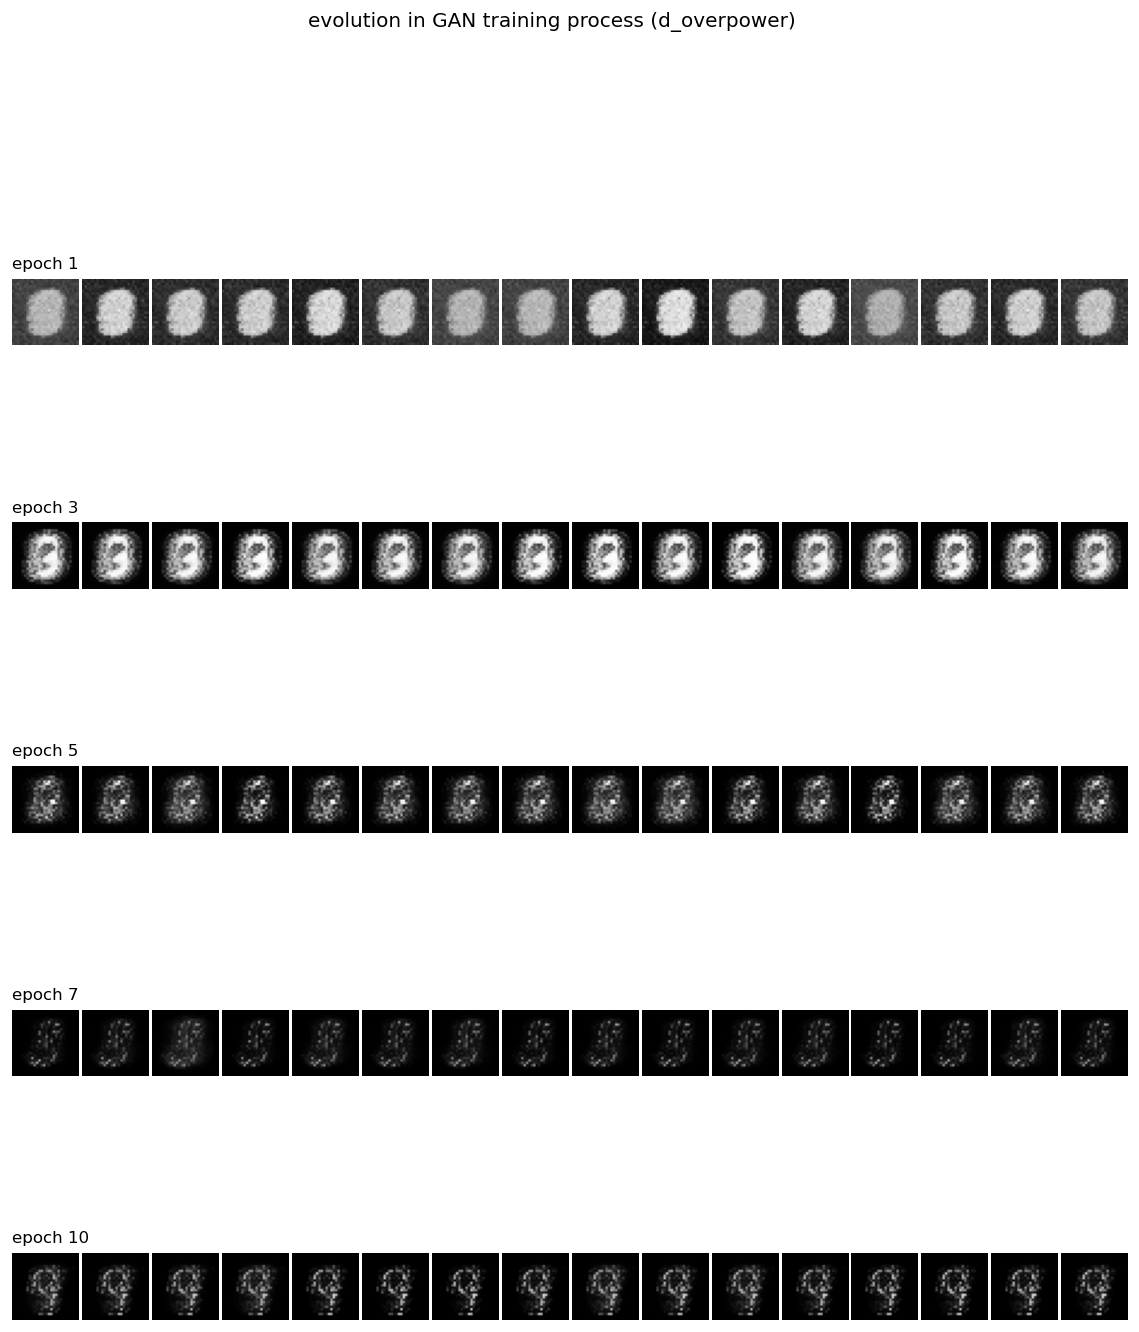

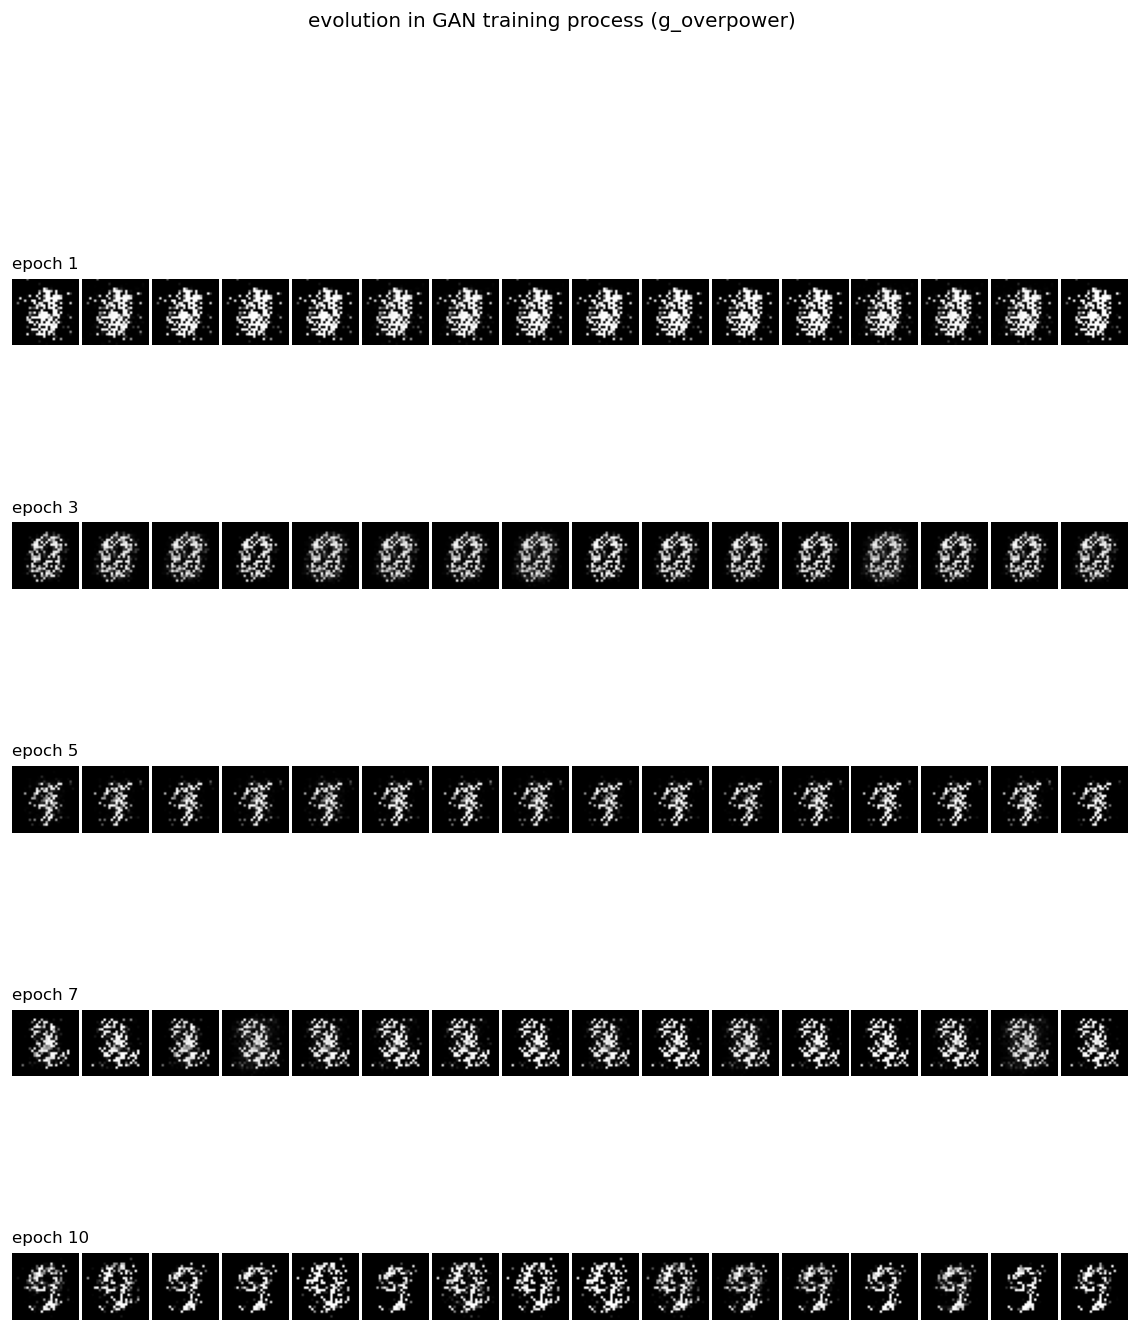

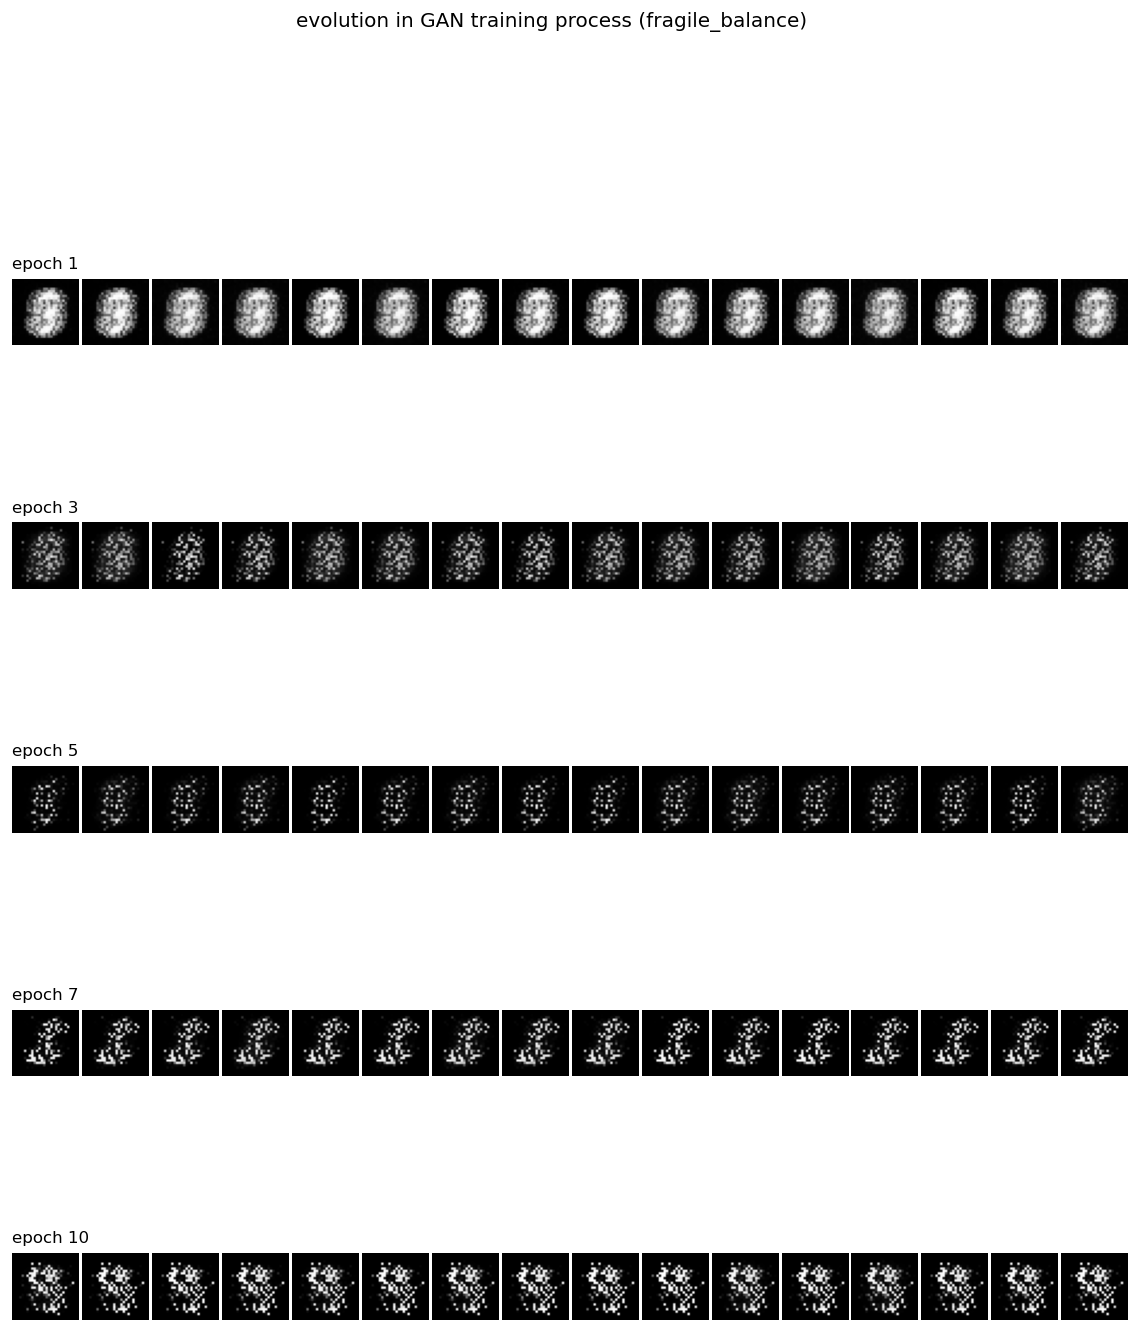

In [13]:
if len(gan_results) == 0:
    print("暂无快照，请先完成 gan_train_step 填空并运行训练。")
else:
    for gan_mode, result in gan_results.items():
        gan_snapshots = result['snapshots']
        epochs_sorted = sorted(gan_snapshots.keys())
        fig = plt.figure(figsize=(12, 2.5 * len(epochs_sorted)))
        outer = gridspec.GridSpec(len(epochs_sorted), 1, wspace=0.1, hspace=0.35)

        for row, ep in enumerate(epochs_sorted):
            imgs = gan_snapshots[ep]
            inner = gridspec.GridSpecFromSubplotSpec(1, 16, subplot_spec=outer[row], wspace=0.05, hspace=0.0)
            for col in range(16):
                ax = plt.Subplot(fig, inner[col])
                ax.imshow(imgs[col, 0], cmap="gray", vmin=0.0, vmax=1.0)
                ax.axis("off")
                if col == 0:
                    ax.set_title(f"epoch {ep}", fontsize=10, loc="left")
                fig.add_subplot(ax)

        plt.suptitle(f"evolution in GAN training process ({gan_mode})", y=1.02)
        plt.show()


**【现象锚定】** 请分别运行 `gan_mode` 的三种设定，观察生成图像的演化与终端状态，并简短回答：
1. 在 `'d_overpower'` 模式下，后期生成的图像呈现出什么病态特征？
2. 在 `'g_overpower'` 模式下，生成器是否能够稳定画出数字结构？
3. 结合课堂中“最优判别器与生成分布错配”的理论，解释为何 GAN 的训练极易发生模式崩溃？（2-3 句）


1. 在本次运行中，`'d_overpower'` 后期的生成图像几乎全部收缩到同一种暗淡、颗粒化的数字模板，16 个样本之间差异很小；训练日志中 D loss 多次接近 0，而 G loss 长时间保持在较高值，说明判别器过强后生成器得到的有效梯度很弱。
2. `'g_overpower'` 不能稳定画出清晰且多样的数字结构：图像在不同 epoch 之间明显震荡，后期虽然局部笔画像数字，但大量样本仍呈现噪点、断裂或同质化形态。
3. 从最优判别器角度看，当生成分布与真实数据分布支撑集错配时，判别器很容易把真假样本分开，GAN 目标会进入饱和或梯度不稳定区域。生成器于是倾向于集中到少数暂时能骗过判别器的模式，而不是覆盖完整数据分布，这就导致模式崩溃。


## 5. 扩散模型 (Diffusion) 与现代 AIGC 推理


### 5.1 前向加噪可视化


**【请填写】**：根据上文推导，在下方围栏内实现 `q_sample` 函数。


In [14]:
def q_sample(x0: torch.Tensor, t: torch.Tensor, alpha_bar: torch.Tensor):
    """
    x0: (B,1,28,28)
    t:  (B,) 0-based 索引
    """
    noise = torch.randn_like(x0)

    # ==========================
    # 【请填写】实现前向加噪
    # 提示：
    # 1. alpha_bar_t = alpha_bar[t].view(-1, 1, 1, 1)
    # 2. x_t = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1 - alpha_bar_t) * noise
    # ==========================
    alpha_bar_t = alpha_bar[t].view(-1, 1, 1, 1)
    x_t = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1 - alpha_bar_t) * noise
    # ==========================

    return x_t, noise


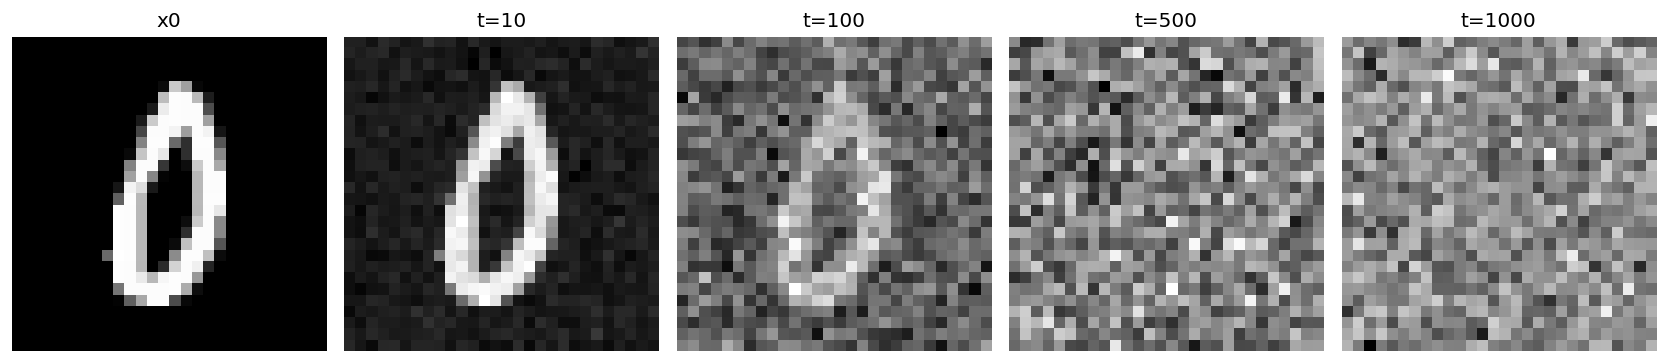

In [15]:
T = 1000
betas = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

x0, _ = next(iter(train_loader))
x0 = x0[:1].to(device)

timesteps = [10, 100, 500, 1000]
fig, axes = plt.subplots(1, len(timesteps) + 1, figsize=(14, 3))
axes[0].imshow(x0[0, 0].detach().cpu(), cmap="gray")
axes[0].set_title("x0")
axes[0].axis("off")

for i, t in enumerate(timesteps, start=1):
    t_idx = torch.tensor([t - 1], device=device, dtype=torch.long)
    x_t, _ = q_sample(x0, t_idx, alpha_bar)
    axes[i].imshow(x_t[0, 0].detach().cpu(), cmap="gray")
    axes[i].set_title(f"t={t}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


**【现象锚定】** 对比 $t=10,100,500,1000$ 的可视化，数字结构在何时开始不可辨认？请用信噪比（SNR）随时间衰减的直觉解释该变化（2-3 句）。

**【请填写】** 在下方 Markdown cell 中作答。


本次可视化中，$t=10$ 时数字 0 基本清晰，$t=100$ 仍可辨认但背景噪声已经明显增强，到了 $t=500$ 数字轮廓基本被噪声淹没，$t=1000$ 接近纯噪声。直觉上，$\bar{\alpha}_t$ 随时间累乘递减，信号项 $\sqrt{\bar{\alpha}_t}x_0$ 逐渐变小，而噪声项 $\sqrt{1-\bar{\alpha}_t}\epsilon$ 逐渐变大；因此 SNR=$\bar{\alpha}_t/(1-\bar{\alpha}_t)$ 持续下降，图像结构会从可见逐步变为不可辨认。


**【理论锚定】** 请比较 VAE 与 Diffusion 的根本差异：  
结构上，VAE 是 Encoder-Decoder 一次映射，Diffusion 是马尔可夫链逐步去噪；  
目标上，VAE 使用 ELBO（重构 + KL），Diffusion 使用噪声预测/score matching。  
请结合本实验中 `reparameterize` 与 `q_sample` 的实现痕迹，说明二者在样本质量、采样速度、训练难度上的典型差异（3-6 句）。

**【请填写】** 在下方 Markdown cell 中作答。


VAE 的 `reparameterize` 实现体现的是一次性潜变量采样：编码器给出 $\mu$ 和 $\log\sigma^2$，再通过 $z=\mu+\sigma\odot\epsilon$ 得到潜变量并一次 decode 出图像，因此采样速度快、结构简单。它的目标是 ELBO，即重构项加 KL 正则，训练相对直接，但像素级重构误差和低维连续潜空间容易产生平均化、模糊或类别交界重影。Diffusion 的 `q_sample` 则体现了马尔可夫加噪链的任意时刻闭式采样，真正生成时需要从噪声逐步反向去噪；这种多步噪声预测/score matching 通常训练和采样成本更高、采样速度更慢，但因为逐步细化样本，典型图像质量和细节保真度往往优于 VAE。


## 6. 思考与附加题 (Flow Matching)

### 6.1 代码分析题

**题目**：Flow Matching（2023）通过直接学习连续时间向量场来定义噪声到数据的传输路径。相比标准扩散模型的离散去噪链，这种表述在训练稳定性、采样步数与路径可控性上可能有哪些理论优势？请结合 ODE / 概率流视角作答。

### 6.2 附加题（选做）

若将标准扩散采样器替换为更高阶 ODE 求解器（如 Heun / DPM-Solver 类思路），在“步数—质量—稳定性”三者之间可能带来什么权衡？请结合本实验第 5 节推理流程给出 2-4 句判断。


**【请填写】** 在下方 Markdown cell 中先完成 6.1；若完成 6.2，请在同一 cell 中续写并标注“附加题”。


6.1 Flow Matching 直接学习连续时间向量场，把简单噪声分布沿 ODE 或概率流路径传输到数据分布，而不是依赖固定离散时间的逐步去噪链。相比标准 DDPM，它的训练目标可以写成对目标速度场的回归，通常比反复匹配许多离散噪声步更直接，梯度信号也更平滑。连续时间表述还允许在采样时选择不同 ODE 求解器、步长和路径设计，因此在减少采样步数、控制噪声到数据的传输轨迹以及稳定数值积分方面具有理论优势。

附加题：如果把标准扩散采样器替换为 Heun 或 DPM-Solver 这类高阶 ODE 求解器，可以在较少步数下获得比一阶方法更小的离散化误差，从而改善“步数—质量”的折中。但高阶方法单步计算更复杂，并且在步数过少、步长过大或模型预测误差较强时仍可能放大数值不稳定，表现为细节损失、过平滑或伪影。因此它通常能加速推理，但需要在采样步数、稳定性和最终质量之间调参。



---

*实验四到此结束。请确认所有必填项已完成并提交本 Notebook。*
